# BEE 4750 Homework 2: Systems Modeling and Simulation

**Name**: Moho Goswami

**ID**: mg2297

> **Due Date**
>
> Thursday, 09/25/25, 9:00pm

## Overview

### Instructions

-   Problem 1 asks you to draw a systems diagram and identify the type
    of a feedback.
-   Problem 2 asks you to model contaminant concentrations in a river
    and use simulation to compare the concentrations to a regulatory
    standard.
-   Problem 3 asks you to explore the implications of an ice-albedo
    feedback in the Earth’s climate system by understanding the
    equilibria of the modeled system and their stabilities.

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

In [1]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()

  Activating project at `c:\Users\mohog\hw2-moho`
   Installed JpegTurbo_jll ─────────────── v3.1.3+0
   Installed InvertedIndices ───────────── v1.3.1
   Installed Accessors ─────────────────── v0.1.42
   Installed WorkerUtilities ───────────── v1.6.1
   Installed SentinelArrays ────────────── v1.4.8
   Installed InlineStrings ─────────────── v1.4.5
   Installed Roots ─────────────────────── v2.2.10
   Installed DataFrames ────────────────── v1.8.0
   Installed WeakRefStrings ────────────── v1.4.2
   Installed PooledArrays ──────────────── v1.4.3
   Installed TableTraits ───────────────── v1.0.1
   Installed DataValueInterfaces ───────── v1.0.0
   Installed Ghostscript_jll ───────────── v9.55.1+0
   Installed ConstructionBase ──────────── v1.6.0
   Installed PrettyTables ──────────────── v3.0.8
   Installed CompositionsBase ──────────── v0.1.2
   Installed Crayons ───────────────────── v4.1.1
   Installed InverseFunctions ──────────── v0.1.17
   Installed CommonSolve ─────────────────

In [21]:
using Plots
using LaTeXStrings
using CSV
using DataFrames
using Roots

## Problems (Total: 30 Points)

### Problem 1 (5 points)

Draw a systems diagram for the relationship between global mean
temperature, atmospheric CO<sub>2</sub> concentrations, and ocean
CO<sub>2</sub> concentrations. What are the signs of the interactions
between these components and why? What does this suggest about the
overall feedback between temperature and the ocean carbon cycle?

System components
* Global mean temperature
* Atmospheric CO2 concentrations
* Ocean CO2 concentrations

Interconnections
* Atmospheric CO2 concentrations INCREASES global mean temperature
* Ocean CO2 concentrations DECREASES atmospheric CO2 concentrations
* Global mean temperature DECREASES Ocean CO2 concentrations

The above relationships, as described in Woodard et al. (2019), reflect how changes in Earth's carbon balance relate to mean temperature. Increasing the atmospheric CO2 concentrations will trap more carbon which stores more heat, thus increasing temperature. In contrast, the Earth's oceans act as a carbon sink and thus when ocean CO2 concentrations increase, the amount of CO2 in the immediate atmosphere is expected to decrease. However, an increase in global mean temperature, including an increase in ocean temperatures, can decrease the natural ability of oceans to dissolve CO2 due to increased stratification and decreased solubility in accordance with Henry's Law.


In [11]:
Pkg.add("GraphRecipes")
Pkg.add("Plots")
using GraphRecipes
using Plots

   Resolving package versions...
  No Changes to `C:\Users\mohog\hw2-moho\Project.toml`
  No Changes to `C:\Users\mohog\hw2-moho\Manifest.toml`
   Resolving package versions...
  No Changes to `C:\Users\mohog\hw2-moho\Project.toml`
  No Changes to `C:\Users\mohog\hw2-moho\Manifest.toml`


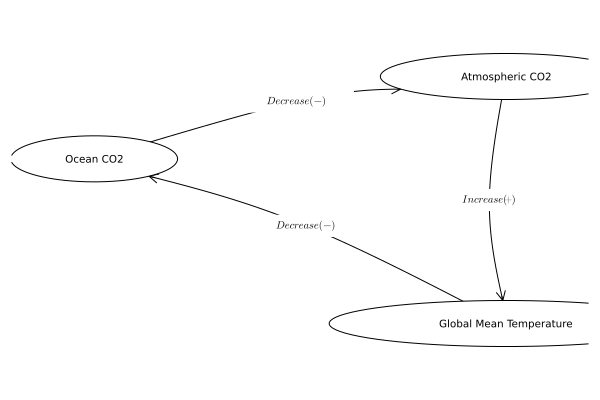

In [16]:
A = [0 0 1;
     1 0 0;
     0 1 0]

names = ["Atmospheric CO2", "Ocean CO2", "Global Mean Temperature"]
edge_labels = Dict((2, 1) => L"Decrease (-)", (1,3) => L"Increase (+)", (3, 2) => L"Decrease (-)")
shapes=[:ellipse :ellipse :ellipse]
xpos = [-0.25, -1.5, -0.25]
ypos = [0.75, 0.5, 0]

p = graphplot(A, names=names,edgelabel=edge_labels, markersize=0.12, markershapes=shapes, markercolor=:white, x=xpos, y=ypos)
display(p)

Considering the overall feedback between temperature and the ocean carbon cycle, this graph suggests that increases in global mean temperature due to increases in atmospheric carbon dioxide levels from human activities such as burning fossil fuels can disrupt the extent of the ocean's natural carbon cycle by reducing its carbon uptake capabilities. In accordance with Henry's Law, which indicates that increasing temperature can decrease the ability of liquids to absorb gas, this means that the oceans have a diminished ability to dissolve carbon dioxide.

> **Tip**
>
> Think about Henry’s law for CO<sub>2</sub>.

### Problem 2 (15 points)

A river which flows at 10 km/d is receiving discharges of wastewater
contaminated with CRUD from two sources which are 15 km apart, as shown
in the Figure below. CRUD decays exponentially in the river at a rate of
0.36 $\mathrm{d}^{-1}$ and is deposited by the atmosphere along the
river at a rate of 54 kg/km/d. 

<figure>
<img src="attachment:figures/river_diagram.png"
alt="Schematic of the river system in Problem 2" />
<figcaption aria-hidden="true">Schematic of the river system in Problem
2</figcaption>
</figure>

#### Problem 2.1

Draw a systems diagram with the relevant control volume(s) denoted and
any relevant in/out-flows between these boxes. How did you decide how
many boxes were needed?


* Control volumes: As depicted in the figure, there are 2 inflows coming from each source with different flow rates and CRUD discharge amounts. Thus, 2 boxes will be needed to isolate the interaction of each of these wastewater discharge flows with the river itself.

![Screenshot](Screenshot%202025-09-22%20145737.png)

#### Problem 2.2

Develop a model for the concentration of CRUD downriver by formulating
and solving the appropriate differential equation(s) analytically.

> **Tip**
>
> Formulate your model in terms of distance downriver, rather than
> leaving it in terms of time from discharge.

In [ ]:
# Defining variables
# k = 0.36/day
# v = velocity, km/day
## k/v = decay per km (REMOVED)
# S = 54 kg/km/day (ADDED)
# C = concentration
# t = time (days)
# x = distance (km)
# Q = flow rate (km/day)

# dC/dt = -k*C(t) ACCOUNTS FOR DECAY, NEED DEPOSITION
# Converting to dC/dx

# Box 1 Inflow = R + D1
# Outflow from Box 1: QrCr + Qd1Cd1
# Box 2 Inflow = D2 + R + D1
# Outflow from Box 2: Qd2Cd2 + Q(r+d1)C(r+d1)

# INCREASE FROM DEPOSITION, S/Q, final units = kg

# Model
# dC/dX = (-k/v) * C + S/Q

Discretizing above differential equation
* dC/dX = (-k/v) * C + S/Q

Applying Euler approximation
* df/dt ~= (f(t + Δt) - f(t)) / Δt
* dC/dX ~= (C(x + Δx) - C(x)) / Δx
* (C(x + Δx) - C(x)) / Δx = (-k/v) * C + S/Q

#### Problem 2.3

Determine if the system in compliance with a regulatory limit of
$2.3\ \text{kg}/(1000 \text{m}^3)$. You can do this analytically or
computationally.

Using
* C(x + Δx) = C(x) + Δx * ((-k/v) * C + S/Q)

![Screenshot](Screenshot%202025-09-25%20175935.png)


### Problem 3 (10 points)

In class, we discussed the ice-albedo feedback and its possible
influence on melting the hypothesized [“Snowball
Earth”](https://en.wikipedia.org/wiki/Snowball_Earth). In this problem,
we’ll introduce a simple model of the Earth’s energy balance with
includes this feedback and examine the stability of the climate.

This simple model of the energy balance (averaged over the entire
planet) is:

<span id="eq-climate">$$
\underbrace{C\frac{dT}{dt}}_{\text{change in heat}} = \underbrace{\frac{(1-\alpha)S}{4}}_{\text{incoming radiation}} - \underbrace{(A - BT)}_{\text{outgoing radiation}} + \underbrace{a\ln \left(\frac{[CO_2]}{[CO_2]_{PI}}\right)}_{\text{greenhouse effect}},
 \qquad(1)$$</span>

where:

-   $T$ is the Earth’s global mean temperature (in $^\circ\text{C}$);
-   $C$ is the heat capacity of the atmosphere and shallow ocean, taken
    to be $51\ \text{J}/\text{m}^2/^\circ\text{C}$;
-   $\alpha$ is the planetary albedo, or the fraction of incoming
    radiation reflected by the Earth, which has a present-day value of
    approximately 0.3;
-   $S$ is the solar constant, or the amount of solar radiation received
    by the Earth averaged over area, which has a present-day value of
    $1368\ \text{W}/\text{m}^2$ but during the Neoproteorozoic Era had a
    value of $1272\ \text{W}/\text{m}^2$ (this is divided by four
    because the Earth is a sphere but $S$ is the radiation captured by a
    disc with radius equal to that of the Earth);
-   $A$ and $B$ are coefficients from the linearization of outgoing
    radiation physics, and have corresponding values
    $B=-1.3\ \text{W}/\text{m}^2/^\circ\text{C}$ (estimated from a
    number of lines of evidence about the sensitivity of outgoing
    radiation to temperature; this is negative due to a sign convention
    about the direction of incoming vs. outgoing radiation) and
    $A=221.2\ \text{W}/\text{m}^2$ (estimated by assuming the
    pre-industrial temperature of $14^\circ\text{C}$ was stable without
    anthropogenic greenhouse gas emissions).

We will ignore the greenhouse effect term as we are considering the
Earth system well before humans were around.

#### Problem 3.1

Discretize the climate model
(<a href="#eq-climate" class="quarto-xref">Equation 1</a>) using forward
Euler integration and a time step of $\Delta t = 1$ yr.

In [ ]:
# this function computes the increment by which the concentration
# is updated at each step
function box_simulate_timestep(T, x, S, C, A, B)
    return ((1-x) * S)/(4*C) - (A-(B*T))/C
end

# this function loops over the timesteps to simulate
# the concentration series
function climate_simulate(x, S, C, A, B, T₀, Tf, Δt)
    # initialize T storage
    # for code simplicity we make the array length T+1 so
    # index 1 is T₀
    steps = Int64(Tf / Δt)
    Ts = zeros(steps + 1)
    Ts[1] = T₀
    for t = 1:steps
        Ts[t+1] = Ts[t] + 
            Δt * box_simulate_timestep(Ts[t], x, S, C, A, B)
    end
    # the first element of T is the initial condition
    return Ts
end
Δt = 1.0 #Time step of 1 year
Tf = 10 #End-time
T₀ = 14 #Pre-industrial temperature
C = 51 #J/m^2/degrees C
x = 0.3 #Planetary albedo alpha
S = 1272 #W/m^2 #Neoproterozoic value
A = 221.2 #W/m^2
B = -1.3 #W/m^2/degrees C
Ts = climate_simulate(x, S, C, A, B, T₀, Tf, Δt)

11-element Vector{Float64}:
 14.0
 13.670588235294119
 13.349573241061131
 13.03674098197526
 12.731882878513145
 12.434795667884378
 12.145281268506933
 11.863146647937148
 11.5882036941662
 11.320269090197257
 11.05916419181968

#### Problem 3.2

Rather than assuming a constant value for the albedo $\alpha$, we will
represent the ice-albedo feedback by letting $\alpha$ depend on $T$:

$$\alpha(T) = 
    \begin{cases} 
        \alpha_i & \quad \text{if } T \leq -10^\circ \text{C} \\
        \alpha_i + (\alpha_0 - \alpha_i)((T+10) / 20) & \quad \text{if } -10^\circ \text{C} \leq T \leq 10^\circ \text{C} \\
        \alpha_0 & \quad \text{if } T \geq 10^\circ \text{C}.
    \end{cases}$$

Let $\alpha_i = 0.5$ and $\alpha_0 = 0.3$. Simulate the simple climate
model using the Neoprotereozoic value of $S$ with temperature-varying
albedo for initial values of $T$ spanning
$-60^\circ\text{C} \leq T_0 \leq 30^\circ\text{C}$ over a period of 200
years. Plot the temperature trajectories. How many equilibria are there
and what are their stabilities?

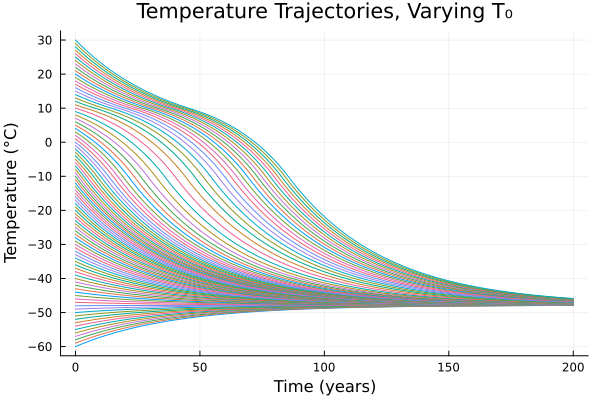

In [11]:
# this function computes the increment by which the concentration
# is updated at each step
function box_simulate_timestep(T, xi, x₀, S, C, A, B)
    if T <= -10
         x = xi
    elseif -10 <= T <= 10
        x = xi + (x₀-xi)*((T+10)/20)
    elseif T >= 10
         x = x₀
    end

    return ((1-x) * S)/(4*C) - (A-(B*T))/C
end
# this function loops over the timesteps to simulate
# the concentration series
function climate_simulate(xi, x₀, S, C, A, B, T₀, Tf, Δt)
    # initialize T storage
    # for code simplicity we make the array length T+1 so
    # index 1 is T₀
    steps = Int64(Tf / Δt)
    Ts = zeros(steps + 1)
    Ts[1] = T₀
    for t = 1:steps
        Ts[t+1] = Ts[t] + 
            Δt * box_simulate_timestep(Ts[t], xi, x₀, S, C, A, B)
    end
    # the first element of T is the initial condition
    return Ts
end
Δt = 1.0 #Time step of 1 year
Tf = 200 #End-time of 200 years
C = 51 #J/m^2/degrees C
x = 0.3 #Planetary albedo alpha
xi = 0.5
x₀ = 0.3
S = 1272 #W/m^2 #Neoproterozoic value
A = 221.2 #W/m^2
B = -1.3 #W/m^2/degrees C

# setting temperature range from -60 C to 30 C
T₀_values = -60.0:1.0:30.0

Ts = Dict{Float64, Vector{Float64}}()
for T₀ in T₀_values
    Ts[T₀] = climate_simulate(xi, x₀, S, C, A, B, T₀, Tf, Δt)
end

plot(yticks = -60:10:30)
for (T₀, T₀_values) in sort(collect(Ts))
    plot!(0:Δt:Tf, T₀_values, label="", lw=1)
end
xlabel!("Time (years)")
ylabel!("Temperature (°C)")
title!("Temperature Trajectories, Varying T₀")

From the graph, it is visible that there is 1 equilibrium at approximately -47 degrees Celsius. This equilibrium is stable: the varying temperature values all converge to the same equilibrium without significant fluctuations.

#### Problem 3.3

One might hypothesize that one cause for the transition from Snowball
Earth (the stable frozen equilibrium from Problem 3.2) was an increasing
amount of incoming solar radiation (as expressed by an increase in $S$).
Examine this hypothesis using our simple model. Is this factor enough to
cause the planet to warm to the pre-industrial temperature of
$14^\circ\text{C}$?

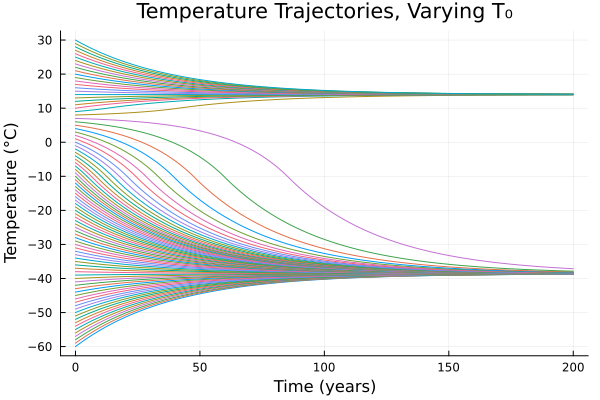

In [12]:
# this function computes the increment by which the concentration
# is updated at each step
function box_simulate_timestep(T, xi, x₀, S, C, A, B)
    if T <= -10
         x = xi
    elseif -10 <= T <= 10
        x = xi + (x₀-xi)*((T+10)/20)
    elseif T >= 10
         x = x₀
    end

    return ((1-x) * S)/(4*C) - (A-(B*T))/C
end
# this function loops over the timesteps to simulate
# the concentration series
function climate_simulate(xi, x₀, S, C, A, B, T₀, Tf, Δt)
    # initialize T storage
    # for code simplicity we make the array length T+1 so
    # index 1 is T₀
    steps = Int64(Tf / Δt)
    Ts = zeros(steps + 1)
    Ts[1] = T₀
    for t = 1:steps
        Ts[t+1] = Ts[t] + 
            Δt * box_simulate_timestep(Ts[t], xi, x₀, S, C, A, B)
    end
    # the first element of T is the initial condition
    return Ts
end
Δt = 1.0 #Time step of 1 year
Tf = 200 #End-time of 200 years
C = 51 #J/m^2/degrees C
x = 0.3 #Planetary albedo alpha
xi = 0.5
x₀ = 0.3
S = 1368 #W/m^2 #MODERN value
A = 221.2 #W/m^2
B = -1.3 #W/m^2/degrees C

# setting temperature range from -60 C to 30 C
T₀_values = -60.0:1.0:30.0

Ts = Dict{Float64, Vector{Float64}}()
for T₀ in T₀_values
    Ts[T₀] = climate_simulate(xi, x₀, S, C, A, B, T₀, Tf, Δt)
end

plot(yticks = -60:10:30)
for (T₀, T₀_values) in sort(collect(Ts))
    plot!(0:Δt:Tf, T₀_values, label="", lw=1)
end
xlabel!("Time (years)")
ylabel!("Temperature (°C)")
title!("Temperature Trajectories, Varying T₀")

After copying and pasting the same code that was used in 3.2 and only increasing the value of S from 1272 to 1368 W/m^2, the graph reaches a second equilibrium at approximately T = 14 degrees Celsius, given that the initial temperature was at least 8 degrees Celsius. Although a higher equilibrium can eventually be reached, changing the amount of solar radiation does not provide the initial boost needed to increase the temperature to at least 8 degrees Celsiuc for the equilibrium shift to occur. As such, while increased solar radiation could plausibly have been a contributing factor to temperature increases over time, based on this graph it would not have been impactful enough to be the sole reason for the transition from "Snowball Earth" to a pre-industrial planetary temperature of 14 degrees C.

## References

List any external references consulted, including classmates.

HW 1 Code
* Generating graph for #1

Lecture 6 slides
* 3.1 Forward Euler code

https://discourse.julialang.org/t/how-to-work-with-intervals-values-in-julia/6433/5
* 3.2

Lecture 5 slides
* 3.2